## Parte 0

In [ ]:
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
# !pip install albumentations

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
import cv2
import time


import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

In [ ]:

import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_d3fdaeaee8be81e14e5601d9a59687c7"

# 1. Baixa o arquivo principal da competição
!kaggle competitions download -c data-science-bowl-2018

# 2. Descompacta o arquivo principal em uma pasta temporária
!unzip -q data-science-bowl-2018.zip -d dataset_temp/

# 3. Descompacta APENAS o stage1_train.zip na pasta final
!unzip -q dataset_temp/stage1_train.zip -d stage1_train/

# 4. Limpa os arquivos pesados para liberar espaço
!rm data-science-bowl-2018.zip
!rm -rf dataset_temp/

100% 358M/358M [00:19<00:00, 19.7MB/s]

replace stage1_train/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
def generateEllipses(img_size):
    # Vamos adicinar um contraste para o fundo da imagem
    bg_intensity = np.random.randint(20,80)
    img = np.full((img_size, img_size), bg_intensity, dtype=np.uint8)

    # Evitar overflow
    mask = np.zeros((img_size, img_size), dtype=np.int32)

    num_ellipses = np.random.randint(15,21)

    # Para cada elipse, define o formato, a posição e a intensidade
    for i in range(1, num_ellipses+1):
        center = (int(np.random.randint(15, img_size-15)), int(np.random.randint(15, img_size-15)))
        axes = (int(np.random.randint(5,25)), int(np.random.randint(5,25)))
        angle = int(np.random.randint(0,180))
        intensity = int(np.random.randint(100,255))

        cv2.ellipse(img, center, axes, angle, 0, 360, intensity, -1)
        cv2.ellipse(mask, center, axes, angle, 0, 360, i, -1)

    std_dev = np.random.uniform(5.0, 30.0)
    noise = np.random.uniform(0, std_dev, (img_size, img_size))

    noisy_img = np.clip(img + noise, 0, 255)

    return noisy_img, mask

img, mask = generateEllipses(128)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Imagem com Ruído e Contraste")
axes[0].axis('off')

axes[1].imshow(mask, cmap='nipy_spectral')
axes[1].set_title("Máscara de Instâncias (ID)")
axes[1].axis('off')
plt.show()

In [ ]:
class EllipsesDataset(Dataset):
  def __init__(self, num_samples) -> None:
     self.num_samples = num_samples

  def __len__(self):
    return self.num_samples

  def __getitem__(self, index):
    img, mask = generateEllipses(128)
    tensor_img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
    tensor_mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
    return tensor_img, tensor_mask

ellip_data_train = EllipsesDataset(800)
ellip_loader_train = DataLoader(ellip_data_train, batch_size=16)

ellip_data_val = EllipsesDataset(200)
ellip_loader_val = DataLoader(ellip_data_val, batch_size=16)

In [ ]:
def binarize_mask(mask):
    return (mask > 0).float()

In [ ]:
def binary_decoder(mask, threshold):
    return (torch.sigmoid(mask) > threshold).float()


def multiclass_decoder(mask, dim):
    return torch.argmax(mask, dim=dim).float()

In [ ]:
# Para treinar com as elipses criadas acima usaremos a U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels) -> None:
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels) -> None:
        super(UNet, self).__init__()
        # Encoder
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(128,256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256,128,kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256,128)
        self.up2 = nn.ConvTranspose2d(128,64,kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128,64)

        # Output
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Passa pelo primeiro bloco e salva
        skip1 = self.conv1(x)
        x = self.pool1(skip1)
        skip2 = self.conv2(x)
        x = self.pool2(skip2)


        x = self.bottleneck(x)
        x = self.up1(x)
        x = torch.cat((skip2, x), dim=1)
        x = self.dec1(x)


        x = self.up2(x)
        x = torch.cat((skip1, x), dim=1)
        x = self.dec2(x)

        return self.final_conv(x)

def compute_semantic_metrics(pred, mask):
    pred_bin = (torch.sigmoid(pred) > 0.5).float()
    mask_bin = (mask > 0).float()
    # print(f"Dimensoes do pred e da mask depois do unsqueeze: {pred.shape}, {mask.shape}")
    intersection = torch.sum((pred_bin*mask_bin))
    union = torch.sum((pred_bin+mask_bin)) - intersection
    iou = intersection / (union + 1e-8)
    dice = 2 * intersection / (torch.sum(pred_bin) + torch.sum(mask_bin) + 1e-8)

    return {'iou': iou.item(), 'dice': dice.item()}

def train_loop(model, optimizer, loader_train, transform_mask, loss):
    loss_train = 0.0
    model.train()
    for img, mask in loader_train:
        img = img.to(device)
        mask = mask.to(device)

        # Aplica uma transformacao na mascara, caso desejado
        if not transform_mask is None:
            mask = transform_mask(mask)

        optimizer.zero_grad()
        pred = model.forward(img)
        loss_value = loss(pred, mask)
        loss_train += loss_value.item()
        loss_value.backward()
        optimizer.step()
    mean_loss_train = loss_train / len(loader_train)
    return mean_loss_train

def val_loop(model, loader_val, transform_mask, loss, decoder, metric_function,**kwargs):
    model.eval()
    loss_val = 0.0
    total_metrics = {}
    img_count = 0
    with torch.no_grad():
        for img, mask_original in loader_val:
            img = img.to(device)
            mask_original = mask_original.to(device)
            # Aplica uma transformacao na mascara, caso desejado
            if not transform_mask is None:
                mask = transform_mask(mask_original)
            else:
                mask = mask_original

            pred = model.forward(img)
            loss_value = loss(pred, mask)
            loss_val += loss_value.item()
            pred = decoder(pred, **kwargs)
            # print(img.shape)
            for b in range(img.shape[0]):
                # Chama a função de métrica que foi passada como parâmetro
                metrics = metric_function(pred[b], mask_original[b])

                # Acumula as métricas dinamicamente
                for key, val in metrics.items():
                    total_metrics[key] = total_metrics.get(key, 0.0) + val
                img_count += 1
    mean_loss_val = loss_val / len(loader_val)
    mean_metrics = {k: v / img_count for k, v in total_metrics.items()}

    return mean_loss_val, mean_metrics

def train_model(
    model,
    loader_train,
    loader_val,
    optimizer,
    epochs=50,
    loss=nn.BCEWithLogitsLoss(),
    transform_mask=None,
    decoder=binary_decoder,
    metric_function = compute_semantic_metrics,
    stop_metric='iou',
    stop_threshold=0.99,
    patience=5,
    **kwargs
):

    time_begin = time.time()
    metrics_history = []
    best_metric = -float('inf')
    for epoch in range(epochs):
        mean_loss_train = train_loop(model, optimizer, loader_train, transform_mask, loss)
        mean_loss_val, mean_metrics = val_loop(model, loader_val, transform_mask, loss, decoder, metric_function,**kwargs)
        metrics_history.append((mean_loss_train, mean_loss_val, mean_metrics))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Val Loss: {mean_loss_val:.4f} | Train Loss: {mean_loss_train:.4f}")
            print(" | ".join([f"Val {k.upper()}: {v:.4f}" for k, v in mean_metrics.items()]))

        current_metric = mean_metrics.get(stop_metric, 0.0)

        if current_metric >= stop_threshold:
            print(f"Early stopping")
            break

        if current_metric > best_metric:
            best_metric = current_metric
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping: Sem melhoria por {patience} epocas consecutivas.")
                break

    time_end = time.time()
    print(f"Train time: {(time_end - time_begin)/60} minutes")

    return metrics_history

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_model(
    model,
    loader_train=ellip_loader_train,
    loader_val=ellip_loader_val,
    optimizer=optimizer,
    epochs=50,
    loss=nn.BCEWithLogitsLoss(),
    transform_mask=binarize_mask,
    decoder=binary_decoder,
    metric_function=compute_semantic_metrics,
    stop_metric='iou',
    stop_threshold=0.99,
    patience=5,
    threshold=0.5
)

Epoch [1/50] | Val Loss: 0.0503 | Train Loss: 0.1247
Val IOU: 0.9965 | Val DICE: 0.9983
Early stopping
Train time: 0.13095107475916545 minutes


[(0.12465194813907146,
  0.050267396351465814,
  {'iou': 0.9965153962373734, 'dice': 0.9982522597908974})]

# Parte 1

In [ ]:
class BBBC038Dataset(Dataset):

    def __init__(self, root, transform):
        self.root = Path(root)

        # Encontra todas as imagens
        self.images = sorted(self.root.glob("*/images/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = self.images[idx]

        # Pasta correspondente a imagem
        sample_dir = image_path.parent.parent

        # Carrega a imagem em um tensor
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # (BGR ==> RGB)

        # Carrega as mascaras
        mask_paths = sorted((sample_dir / "masks").glob("*.png"))

        masks = []

        for i in range(len(mask_paths)):
            mask_path = mask_paths[i]
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask != 0) * (i + 1)
            masks.append(mask)

        mask = np.stack(masks).max(0).astype(int)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.unsqueeze(0).float()

        return image, mask

In [ ]:
# Pipeline para redimensionamento das imagens
train_transform = A.Compose([
    # Forca image e mask para 256x256
    A.Resize(height=256, width=256),

    # Normaliza os pixels para o padrao ImageNet
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),

    # Converte os arrays Numpy para Tensores do PyTorch e ajusta as dimensoes ((H, W, C) ==> (C, H, W))
    ToTensorV2()
])

batch_size = 16

dataset = BBBC038Dataset("stage1_train", train_transform)
# dataloader = DataLoader(dataset, batch_size=batch_size)
train_dataset, val_dataset = torch.utils.data.dataset.random_split(dataset, [0.8,0.2])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

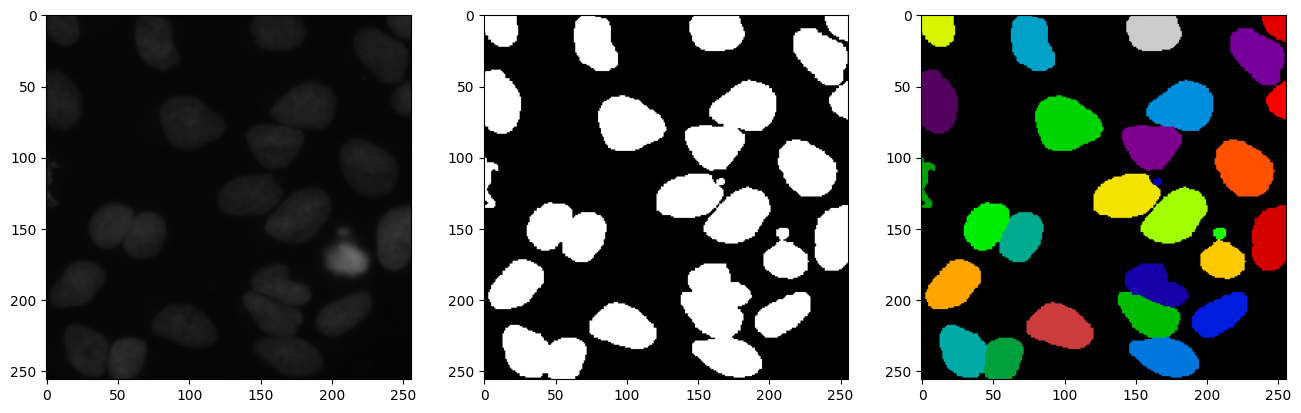

In [ ]:
for i, (img, mask) in enumerate(train_dataloader):
    img = img.to(device)
    mask = mask.to(device)

    # Desfaz a normalizacao da imagem
    img_plot = img[0].cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_plot = (img_plot * std) + mean
    img_plot = np.clip(img_plot, 0, 1)


    fig, axes = plt.subplots(1, 3, figsize=(16, 10))
    mask = mask[0][0].cpu().numpy()
    axes[0].imshow(img_plot)
    axes[1].imshow(mask != 0, cmap='gray')
    axes[2].imshow(mask, cmap='nipy_spectral')
    break

In [ ]:
# Treino do modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_model(
    model,
    loader_train=train_dataloader,
    loader_val=val_dataloader,
    optimizer=optimizer,
    epochs=1,
    loss=nn.BCEWithLogitsLoss(),
    transform_mask=binarize_mask,
    decoder=binary_decoder,
    metric_function=compute_semantic_metrics,
    stop_metric='iou',
    stop_threshold=0.99,
    patience=5,
    threshold=0.5
)

Epoch [1/1] | Val Loss: 0.2424 | Train Loss: 0.3159
Val IOU: 0.6109 | Val DICE: 0.7369
Train time: 1.4825358708699545 minutes


[(0.3159302683437572,
  0.24244212110837302,
  {'iou': 0.61089541175083, 'dice': 0.7369083739650338})]

In [ ]:
# TRENAR COM TRAIN + VAL!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

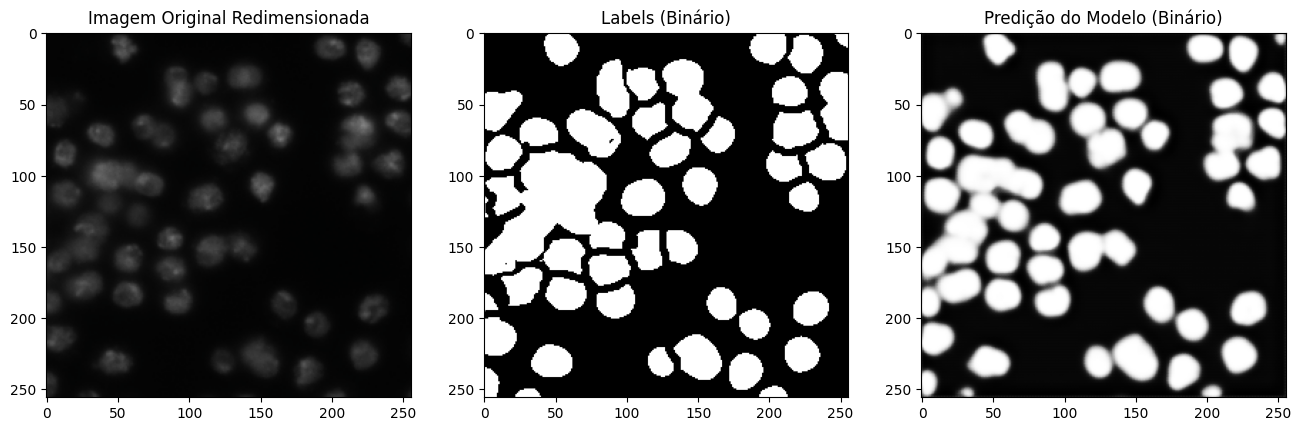

In [ ]:
with torch.no_grad():
  # MODIFICAR DEPOIS PARA LOADER DE TESTE!!!!!!!!!!!!!!!!!
    for i, (img, mask) in enumerate(val_dataloader):
      if i != 0: continue
      img = img.to(device)
      mask = mask.to(device)
      mask = (mask > 0).float()


      # Desfaz a normalizacao da imagem
      img_plot = img[0].cpu().permute(1, 2, 0).numpy()
      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      img_plot = (img_plot * std) + mean
      img_plot = np.clip(img_plot, 0, 1)
      pred = model(img)
      pred = torch.sigmoid(pred)[0].cpu().numpy()

      fig, axes = plt.subplots(1, 3, figsize=(16, 10))
      axes[0].imshow(img_plot)
      axes[0].set(
        title="Imagem Original Redimensionada"
      )
      axes[1].imshow(mask[0][0].cpu().numpy(), cmap='gray')
      axes[1].set(
        title="Labels (Binário)"
      )
      axes[2].imshow(pred[0], cmap='gray')
      axes[2].set(
        title="Predição do Modelo (Binário)"
      )
      break

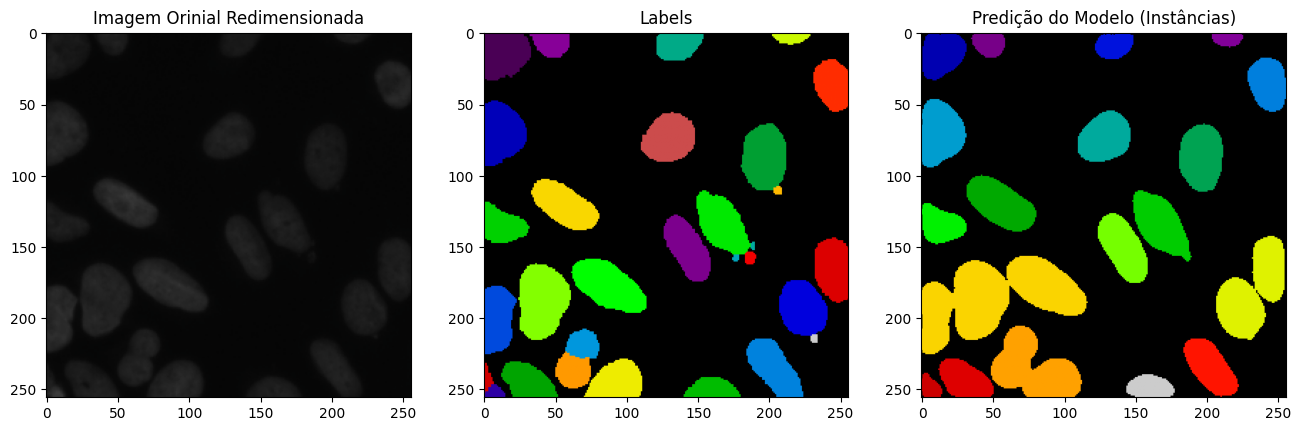

In [ ]:
# Extrair instâncias pelo método ingênuo
from scipy.ndimage import label
import matplotlib.colors as mcolors

with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
      img = img.to(device)
      mask = mask.to(device)

      # Desfaz a normalizacao da imagem
      img_plot = img[0].cpu().permute(1, 2, 0).numpy()
      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      img_plot = (img_plot * std) + mean
      img_plot = np.clip(img_plot, 0, 1)

      pred = model(img)
      pred = torch.sigmoid(pred)[0].cpu().numpy()
      # Limiar
      pred_bin = (pred > 0.5).astype(int)
      # Componentes Conexas
      inst_matrix, num_obj = label(pred_bin[0])

      fig, axes = plt.subplots(1, 3, figsize=(16, 10))
      axes[0].imshow(img_plot)
      axes[0].set(
        title="Imagem Orinial Redimensionada"
      )
      axes[1].imshow(mask[0][0].cpu().numpy(), cmap='nipy_spectral')
      axes[1].set(
        title="Labels"
      )
      axes[2].imshow(inst_matrix, cmap='nipy_spectral')
      axes[2].set(
        title="Predição do Modelo (Instâncias)"
      )
      break

In [ ]:
def compute_intersection(mask_true, mask_pred):
    mask_true = np.asarray(mask_true)
    mask_pred = np.asarray(mask_pred)

    num_true_classes = int(np.max(mask_true)) + 1
    num_pred_classes = int(np.max(mask_pred)) + 1

    # Calcula a quantidade de pixels de cada instancia na mascara real
    true_inst_counts = np.unique_counts(mask_true)
    true_instances_counts = dict(zip(true_inst_counts.values, true_inst_counts.counts))

    # Calcula a quantidade de pixels de cada instancia na mascara prevista
    pred_inst_counts = np.unique_counts(mask_pred)
    pred_instances_counts = dict(zip(pred_inst_counts.values, pred_inst_counts.counts))

    # Cria a matriz de interseções com zeros
    intersect_matrix = np.zeros((num_pred_classes, num_true_classes), dtype=float)
    fn_matrix = intersect_matrix.copy()
    fp_matrix = intersect_matrix.copy()

    intersect = np.hstack([mask_pred.reshape(-1, 1), mask_true.reshape(-1, 1)]).astype(int)

    # Soma as intersecoes a matrix
    intersect_values, intersect_counts = np.unique(intersect, axis=0, return_counts=True)
    for (pred_inst, true_inst), qtd in zip(list(intersect_values), intersect_counts):
        qtd = float(qtd)
        intersect_matrix[pred_inst][true_inst] += qtd
        fn_matrix[pred_inst][true_inst] = true_instances_counts.get(true_inst, 0) - qtd
        fp_matrix[pred_inst][true_inst] = pred_instances_counts.get(pred_inst, 0) - qtd


    # Computa o iou
    iou_matrix = intersect_matrix.copy()
    iou_matrix[iou_matrix != 0] = iou_matrix[iou_matrix != 0] / (
        iou_matrix[iou_matrix != 0]
        + fn_matrix[iou_matrix != 0]
        + fp_matrix[iou_matrix != 0]
    )

    return intersect_matrix, iou_matrix

In [ ]:
def greedy_match(iou, predicts):
    iou = iou.copy()
    # Faz o casamento de forma gulosa
    matches = np.full(shape=predicts, fill_value=0.0)
    for _ in range(predicts):
        pred_mxs = iou.max(axis=1)
        greedy_pred_isnt = pred_mxs.argmax()
        greedy_true_isnt = iou[greedy_pred_isnt].argmax()
        greedy_iou = iou[greedy_pred_isnt, greedy_true_isnt].max()

        # Apaga virtualmente as instancias prevista e verdadeira
        iou[greedy_pred_isnt, :] = -1
        iou[:, greedy_true_isnt] = -1

        matches[greedy_pred_isnt] = greedy_iou

    return matches


def test_limiares(iou, limiares, predicts, trues):
    matches = greedy_match(iou, predicts)

    true_positives = []
    false_positves = []
    false_negatives = []
    average_precisions = []

    # Calcula TP, FP e FN para cada limiar
    for limiar in limiares:
        tp = (matches >= limiar).sum()
        fp = predicts - tp
        fn = trues - tp
        true_positives.append(tp)
        false_positves.append(fp)
        false_negatives.append(fn)
        average_precisions.append(tp / (tp + fp + fn))

    return true_positives, false_positves, false_negatives, average_precisions


def compute_metrics(iou_matrix, limiares):
    iou = iou_matrix[1:, 1:]
    predicts, trues = iou.shape
    true_positives, false_positves, false_negatives, average_precisions = test_limiares(iou, limiares, predicts, trues)
    mean_average_precision = np.mean(average_precisions)
    abs_count_error = np.abs(predicts - trues)

    return true_positives, false_positves, false_negatives, float(mean_average_precision), float(abs_count_error)

In [ ]:
mask_true = None
mask_pred = None
with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)
        pred = torch.sigmoid(pred)[0].cpu().numpy()
        # Limiar
        pred_bin = (pred > 0.5).astype(int)
        # Componentes Conexas
        inst_matrix, num_obj = label(pred_bin)

        mask_true = mask[0][0].cpu().numpy()
        mask_pred = inst_matrix[0]

        break

In [ ]:
intersect_matrix, iou_matrix = compute_intersection(mask_true=mask_true, mask_pred=mask_pred)

true_positives, false_positves, false_negatives, mean_average_precision, abs_count_error = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))

In [ ]:
np.vstack([true_positives, false_positves, false_negatives]).T

array([[21,  9, 28],
       [21,  9, 28],
       [20, 10, 29],
       [20, 10, 29],
       [20, 10, 29],
       [18, 12, 31],
       [16, 14, 33],
       [15, 15, 34],
       [ 6, 24, 43],
       [ 1, 29, 48]])

Para realizar o matching entre a nossa mask e o que foi predito por nosso modelo, temos duas opções a considerar: guloso por IoU decrescente ou Hungarian.

Antes de documentar os métodos, vale a pena descrever como obtivemos a matriz que será usada no matching: calcula-se a quantidade de pixels de cada instância, tanto na mask quanto no que foi previsto; após isto, coloca-se cada pixel da mask ao lado de sua previsao correspondente e conta-se a quantidade de ocorrências de cada par (classe real, classe prevista); com isto, passamos por cada par único usando a quantidade de ocorrências desse par e as quantidades de ocorrências da classe prevista e da classe real, obtendo então os FPs e os FNs (previstos = interseção + FPs e verdadeiros = interseção + FNs); com a interseção e as áreas totais (ou FPs e FNs), calcula-se a união e, consequentemente, o IoU de cada par  

O método guloso por IoU decrescente, que na nossa aplicação é $O(n^{2})$, vai pegar a célula de maior valor, atribuir à previsão linha a classe coluna, remover as linhas e colunas correspondentes a essa célula e repetir esse procedimento até que não sobre mais nenhum IoU aceitável (nosso threshold).

Já o Hungarian, também chamado de algoritmo de Kuhn-Munkres, é um algoritmo de complexidade $O(n^{3})$ que pode ser usado para encontrar emparelhamentos de peso máximo em grafos bipartidos, o que às vezes é chamado de problema de atribuição.

Como o objetivo desta etapa não é usar o melhor algoritmo possível e temos uma quantidade considerável de dados, optamos por seguir com o método guloso

In [ ]:
ax_x_density = []
ax_y_error = []

with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
        img = img.to(device)
        mask = mask.cpu().numpy()

        pred = model(img)
        pred = torch.sigmoid(pred).cpu().numpy()

        for b in range(img.shape[0]):
            # Trata a Previsão (Limiar + Componentes Conexos)
            pred_bin = (pred[b, 0] > 0.5).astype(int)
            inst_matrix_pred, _ = label(pred_bin)

            # Trata o Gabarito
            inst_matrix_true = (mask[b, 0]).astype(int)

            intersect_matrix, iou_matrix = compute_intersection(
                mask_true=inst_matrix_true,
                mask_pred=inst_matrix_pred
            )

            # Se a imagem for totalmente preta (sem células), pulamos para evitar erro
            if iou_matrix.shape == (1, 1):
                continue

            true_positives, false_positves, false_negatives, mean_average_precision, abs_count_error = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))

            ax_x_density.append(iou_matrix.shape[1] - 1)
            ax_y_error.append(abs_count_error)

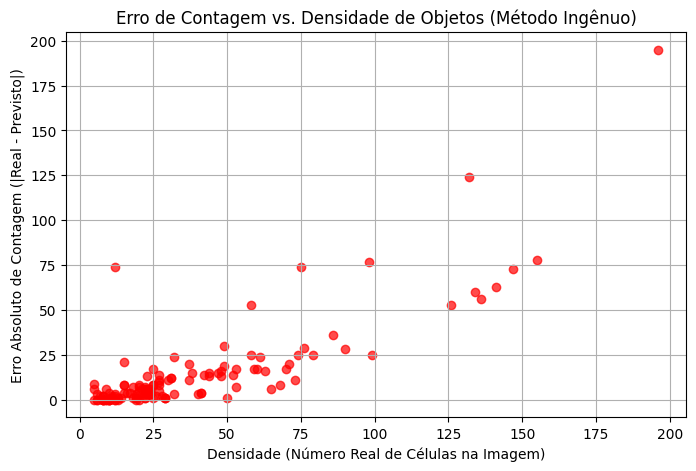

In [ ]:
ax_x_density = np.array(ax_x_density)
ax_y_error = np.array(ax_y_error)
plt.figure(figsize=(8, 5))
plt.scatter(ax_x_density[ax_x_density < 200], ax_y_error[ax_x_density < 200], alpha=0.7, color='red')
plt.title("Erro de Contagem vs. Densidade de Objetos (Método Ingênuo)")
plt.xlabel("Densidade (Número Real de Células na Imagem)")
plt.ylabel("Erro Absoluto de Contagem (|Real - Previsto|)")
plt.grid(True)
plt.show()

# Parte 2

In [ ]:
def border_mask(mask, kernel_size=3):
    mask = binarize_mask(mask)
    # Aplica o maxpooling ao negativo da mascara, ou seja, trara 0 caso haja contato com algum fundo (fundo ou borda) e 1 caso o contrario
    padding = kernel_size // 2
    mask_interior = -F.max_pool2d(-mask, kernel_size=kernel_size, stride=1, padding=padding)

    return ((2 * mask) - mask_interior).long().squeeze(1) # Fronteira = 2, Interior = 1 e Fundo = 0

In [ ]:
from skimage.segmentation import watershed

def watershed_decoder(mask):
    images = mask.shape[0]
    # Considera somente regioes internas
    interior_mask = (mask == 1)

    # Monta as componentes conexas
    interior_mask = np.stack(
        [
            label(
                interior_mask[i].squeeze(0).cpu().numpy()
            )[0]
            for i in range(images)
        ]
    )

    # Expande (Watershed)
    cell_pixes = (mask != 0).float().cpu().numpy()
    image = np.zeros_like(interior_mask[0])
    return torch.stack(
        [
            torch.tensor(watershed(image=image, markers=interior_mask[i], mask=cell_pixes[i]))
            for i in range(images)
        ]
    ).unsqueeze(1)

# Funções auxiliares para usar na train_model()
def multiclass_watershed_decoder(pred_logits, **kwargs):
    pred_classes = torch.argmax(pred_logits, dim=1)
    return watershed_decoder(pred_classes)

def compute_instance_metrics_wrapper(pred_inst, mask_true_inst):
    pred_np = pred_inst.cpu().numpy()
    mask_true_np = mask_true_inst.cpu().numpy()

    intersect_matrix, iou_matrix = compute_intersection(mask_true_np, pred_np)

    if iou_matrix.shape == (1, 1): # Se não previu nada, o mAP é 0
        return {'map': 0.0, 'abs_err': 0.0}

    _, _, _, mean_ap, abs_err = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))

    return {'map': mean_ap, 'abs_err': abs_err}

In [ ]:
def get_weights(loader, classes, transoform_mask=None, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    total_counts = torch.zeros(classes, dtype=torch.float64).to(device)
    with torch.no_grad():
        for i, (img, mask) in enumerate(loader):
            mask = mask.to(device)
            if not transoform_mask is None:
                mask = transoform_mask(mask)

            # Estava dando problema caso não tivesse uma das classes, coloquei um bincount pra contornar isso
            counts = torch.bincount(mask.flatten(), minlength=classes)
            total_counts += counts

    mx = total_counts.max()
    weights = mx / (total_counts + 1e-8)

    return weights.float()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
weight = get_weights(loader=train_dataloader, classes=3, transoform_mask=border_mask)

train_model(
    model,
    loader_train=train_dataloader,
    loader_val=val_dataloader,
    optimizer=optimizer,
    epochs=5,
    loss=nn.CrossEntropyLoss(weight=weight),
    transform_mask=border_mask,
    decoder=multiclass_watershed_decoder,
    metric_function=compute_instance_metrics_wrapper,
    stop_metric='map',
    stop_threshold=0.99,
    patience=5,
    dim=1
)

Epoch [1/5] | Val Loss: 1.6125 | Train Loss: 0.6952
Val MAP: 0.0364 | Val ABS_ERR: 37.7761
Epoch [5/5] | Val Loss: 0.3867 | Train Loss: 0.3851
Val MAP: 0.2930 | Val ABS_ERR: 11.7164
Train time: 8.030986920992534 minutes


[(0.6951765225214117,
  1.6125497155719333,
  {'map': 0.03642895320736232, 'abs_err': 37.776119402985074}),
 (0.4750128011493122,
  0.45913083685768974,
  {'map': 0.1691302683814076, 'abs_err': 22.746268656716417}),
 (0.4400346270378898,
  0.48262832562128705,
  {'map': 0.13026733540392907, 'abs_err': 25.70149253731343}),
 (0.3957664116340525,
  0.548261649078793,
  {'map': 0.29012934252384504, 'abs_err': 13.947761194029852}),
 (0.3851071210468517,
  0.38672184281879,
  {'map': 0.2929893317453764, 'abs_err': 11.716417910447761})]

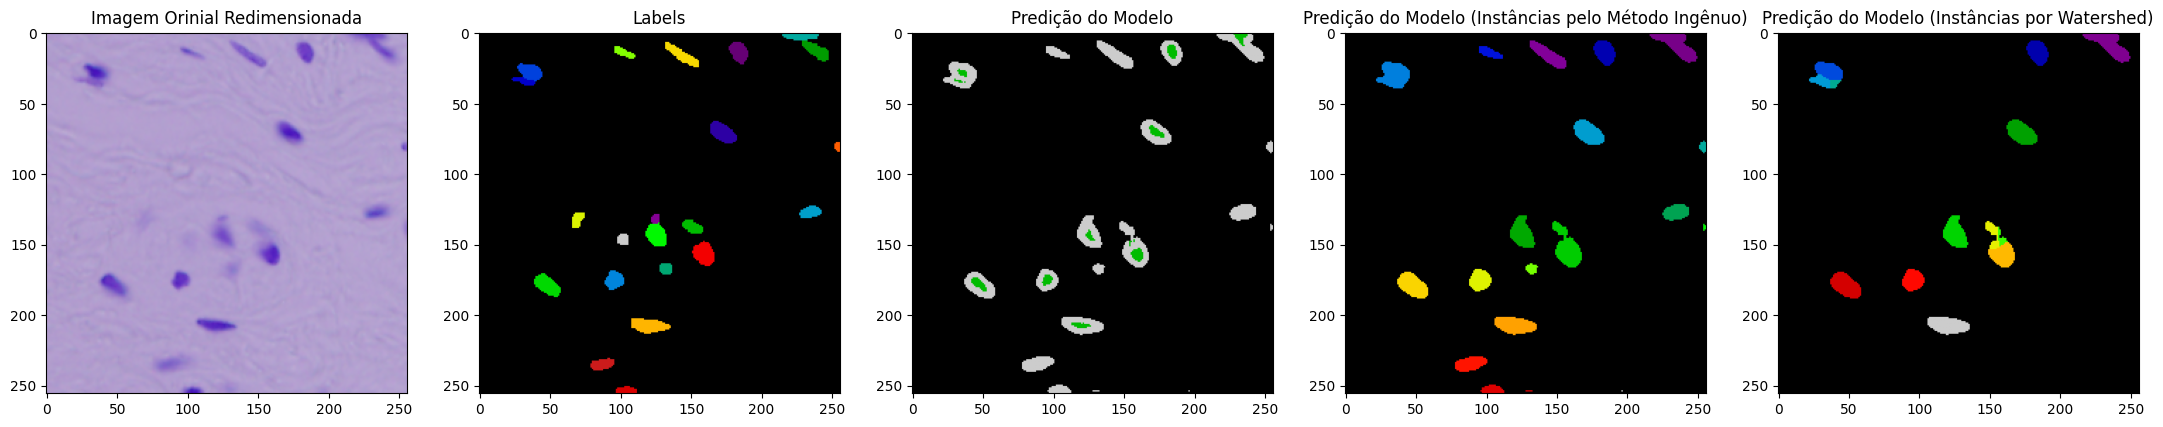

In [ ]:
with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
        img = img.to(device)
        mask = mask.to(device)

        # Desfaz a normalizacao da imagem
        img_plot = img[0].cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_plot = (img_plot * std) + mean
        img_plot = np.clip(img_plot, 0, 1)

        pred = model(img)
        pred = torch.argmax(pred, dim=1).cpu().numpy().astype(int)
        # Componentes Conexas
        inst_matrix, num_obj = label(pred[0])

        # Watershed
        mask_watershed = watershed_decoder(torch.tensor(pred))

        fig, axes = plt.subplots(1, 5, figsize=(27, 10))
        axes[0].imshow(img_plot)
        axes[0].set(
            title="Imagem Orinial Redimensionada"
        )
        axes[1].imshow(mask[0][0].cpu().numpy(), cmap='nipy_spectral')
        axes[1].set(
            title="Labels"
        )
        axes[2].imshow(pred[0], cmap='nipy_spectral')
        axes[2].set(
            title="Predição do Modelo"
        )
        axes[3].imshow(inst_matrix, cmap='nipy_spectral')
        axes[3].set(
            title="Predição do Modelo (Instâncias pelo Método Ingênuo)"
        )
        axes[4].imshow(mask_watershed[0][0], cmap='nipy_spectral')
        axes[4].set(
            title="Predição do Modelo (Instâncias por Watershed)"
        )
        break

# Parte 3

Aqui, optamos por seguir com os Eixos 1 (Pool indices e Skip connections) e 2

In [ ]:
# Eixo 1: SegNet
class SegNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SegNet, self).__init__()
        # Encoder (Igual ao da UNet)
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        self.conv2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        # Bottleneck
        self.bottleneck = DoubleConv(128,256)

        # Decoder
        self.unpool1 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256,128)
        self.unpool2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128,64)

        # Output
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x = self.conv1(x)
        x, idx1 = self.pool1(x)
        x = self.conv2(x)
        x, idx2 = self.pool2(x)

        x = self.bottleneck(x)

        x = self.dec1(x)
        x = self.unpool1(x,idx2)
        x = self.dec2(x)
        x = self.unpool2(x,idx1)

        return self.final_conv(x)

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

resultados_mAP = [[],[]]
weight = get_weights(loader=train_dataloader, classes=3, transoform_mask=border_mask)

for seed in [3,20]:
    set_seed(seed)

    # Treino do modelo
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = UNet(in_channels=3, out_channels=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    metrics = train_model(
        model,
        loader_train=train_dataloader,
        loader_val=val_dataloader,
        optimizer=optimizer,
        epochs=1,
        loss=nn.CrossEntropyLoss(weight=weight),
        transform_mask=border_mask,
        decoder=multiclass_watershed_decoder,
        metric_function=compute_instance_metrics_wrapper,
        stop_metric='map',
        stop_threshold=0.99,
        patience=5,
        dim=1
    )

    best_map = max([epoch_data[2].get('map', 0) for epoch_data in metrics])
    resultados_mAP[0].append(best_map)

    # Treino do modelo
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SegNet(in_channels=3, out_channels=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    metrics = train_model(
        model,
        loader_train=train_dataloader,
        loader_val=val_dataloader,
        optimizer=optimizer,
        epochs=1,
        loss=nn.CrossEntropyLoss(weight=weight),
        transform_mask=border_mask,
        decoder=multiclass_watershed_decoder,
        metric_function=compute_instance_metrics_wrapper,
        stop_metric='map',
        stop_threshold=0.99,
        patience=5,
        dim=1
    )

    best_map = max([epoch_data[2].get('map', 0) for epoch_data in metrics])
    resultados_mAP[1].append(best_map)

print(f"\nResultados do Eixo 1:")
print(f"UNet: Media {np.mean(resultados_mAP[0])} Desvio Padrão {np.std(resultados_mAP[0])}")
print(f"SegNet: Media {np.mean(resultados_mAP[1])} Desvio Padrão {np.std(resultados_mAP[1])}")


Epoch [1/1] | Val Loss: 0.6505 | Train Loss: 0.7351
Val MAP: 0.0872 | Val ABS_ERR: 41.8657
Train time: 1.5278586586316427 minutes
Epoch [1/1] | Val Loss: 0.8018 | Train Loss: 0.9142
Val MAP: 0.0109 | Val ABS_ERR: 526.5746
Train time: 1.5699832081794738 minutes
Epoch [1/1] | Val Loss: 0.6431 | Train Loss: 0.6693
Val MAP: 0.0770 | Val ABS_ERR: 25.7463
Train time: 1.5252642711003621 minutes
Epoch [1/1] | Val Loss: 0.8494 | Train Loss: 0.9537
Val MAP: 0.0021 | Val ABS_ERR: 3348.4552
Train time: 3.8060360232988995 minutes

Resultados do Eixo 1:
UNet: Media 0.08208973676183112 Desvio Padrão 0.005113809802283001
SegNet: Media 0.006492978900066347 Desvio Padrão 0.0043890825545568725


In [ ]:
import torch.nn.functional as F

# Eixo 2: Baseline (CE) -> Ablação 1 (CE balanceada) -> Ablação 2 (Focal) -> Ablação 3 (Focal balanceada)
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

In [ ]:
resultados_mAP = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for seed in [23,24]:

    for balanced in [False, True]:
        resultados_mAP.append([])

        if balanced:
            weight = get_weights(loader=train_dataloader, classes=3, transoform_mask=border_mask)
        else:
            weight = None

        for i, gamma in enumerate([0,1,2,5]):
            set_seed(seed)
            model = UNet(in_channels=3, out_channels=3).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
            resultados_mAP[int(balanced)].append([])

            # gamma = 0 vira a CE
            if gamma == 0:
                loss = nn.CrossEntropyLoss(weight=weight)
            else:
                loss = FocalLoss(weight=weight, gamma=gamma)

            metrics = train_model(
                model,
                loader_train=train_dataloader,
                loader_val=val_dataloader,
                optimizer=optimizer,
                epochs=1,
                loss=loss,
                transform_mask=border_mask,
                decoder=multiclass_watershed_decoder,
                metric_function=compute_instance_metrics_wrapper,
                stop_metric='map',
                stop_threshold=0.99,
                patience=5,
                dim=1
            )

            best_map = max([epoch_data[2].get('map', 0) for epoch_data in metrics])
            resultados_mAP[int(balanced)][i].append(best_map)

    print(f"\nResultados Eixo 2:")
    print(f"No balance")
    print(f"CE: Media {np.mean(resultados_mAP[0][0])} Desvio Padrão {np.std(resultados_mAP[0][0])}")
    for i, gamma in enumerate([1,2,5]):
        print(f"Focal Gamma {gamma}: Media {np.mean(resultados_mAP[0][i+1])} Desvio Padrão {np.std(resultados_mAP[0][i+1])}")

    print(f"With balance")
    print(f"CE: Media {np.mean(resultados_mAP[1][0])} Desvio Padrão {np.std(resultados_mAP[1][0])}")
    for i, gamma in enumerate([1,2,5]):
        print(f"Focal Gamma {gamma}: Media {np.mean(resultados_mAP[1][i+1])} Desvio Padrão {np.std(resultados_mAP[1][i+1])}")
